# 02 - Analytical zones and validation

Defines the four analytical Hajj zones as circles around Haram/Central Makkah, Mina,
Muzdalifah and Arafat, assigns each facility to a zone, and runs data-quality checks.

**Output:** zone geometries and zoned facilities.

In [ ]:
# If needed:
# %pip install -U pandas numpy geopandas osmnx folium plotly pyarrow shapely openpyxl

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import folium
import plotly.express as px
from shapely.geometry import Point
from branca.element import Element

PROJECT_ROOT = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents]
     if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the repository root or its notebooks directory.")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MAP_DIR = PROJECT_ROOT / "outputs" / "maps"
REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"
for p in [PROCESSED_DIR, MAP_DIR, REPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

ox.settings.use_cache = True
ox.settings.log_console = True
ox.settings.requests_timeout = 180


## 1. Load notebook 01 output


In [ ]:
candidate_files = [
    PROCESSED_DIR / "hajj_medical_locations_v1.gpkg",
    PROCESSED_DIR / "hajj_medical_locations_v1.parquet",
    PROCESSED_DIR / "hajj_medical_locations_v1.geojson",
]
facility_path = next((p for p in candidate_files if p.exists()), None)
if facility_path is None:
    raise FileNotFoundError(
        "Run notebook 01 first. No processed medical-infrastructure file was found."
    )

locations = (
    gpd.read_parquet(facility_path)
    if facility_path.suffix == ".parquet"
    else gpd.read_file(facility_path)
).to_crs(4326)

print("Loaded medical infrastructure:", facility_path)
print("Infrastructure records:", len(locations))
display(locations["category"].value_counts())


Loaded medical infrastructure: hajj_drone_project\data\processed\hajj_medical_locations_v1.gpkg
Infrastructure records: 216


category
pharmacy                  59
hospital                  53
clinic                    52
doctors                   44
seasonal_health_center     5
other_healthcare           2
ambulance_station          1
Name: count, dtype: int64

## 2. Resolve principal Hajj-area centers from OpenStreetMap


In [ ]:
ZONE_RADII_M = {"Haram_Makkah":4000, "Mina":3000, "Muzdalifah":2500, "Arafat":3500}

PLACE_QUERIES = {
    "Haram_Makkah":["Masjid al-Haram, Makkah, Saudi Arabia","Al-Masjid al-Haram, Mecca, Saudi Arabia"],
    "Mina":["Mina, Makkah, Saudi Arabia","Mina Saudi Arabia"],
    "Muzdalifah":["Muzdalifah, Makkah, Saudi Arabia","Muzdalifah Saudi Arabia"],
    "Arafat":["Mount Arafat, Makkah, Saudi Arabia","Arafat, Makkah, Saudi Arabia"],
}

def geocode_first_valid(queries):
    errors=[]
    for q in queries:
        try:
            lat,lon=ox.geocode(q)
            return q,float(lat),float(lon)
        except Exception as e:
            errors.append(str(e))
    raise RuntimeError("No geocoding query succeeded: "+" | ".join(errors))

records=[]
for zone,queries in PLACE_QUERIES.items():
    q,lat,lon=geocode_first_valid(queries)
    records.append({"zone":zone,"matched_query":q,"latitude":lat,"longitude":lon,
                    "radius_m":ZONE_RADII_M[zone]})

zone_centers=gpd.GeoDataFrame(records,
    geometry=[Point(r["longitude"],r["latitude"]) for r in records],crs=4326)
display(zone_centers[["zone","matched_query","latitude","longitude","radius_m"]].sort_values("longitude"))


,zone,matched_query,latitude,longitude,radius_m
0,Haram_Makkah,"Masjid al-Haram, Makkah, Saudi Arabia",21.424559,39.824871,4000
1,Mina,"Mina, Makkah, Saudi Arabia",21.415356,39.892506,3000
2,Muzdalifah,"Muzdalifah, Makkah, Saudi Arabia",21.386346,39.915147,2500
3,Arafat,"Arafat, Makkah, Saudi Arabia",21.355525,39.982138,3500


## 3. Construct initial analytical zones

The four zones are analytical circles centred on the geocoded locations above, running
west to east: Haram/Makkah, Mina, Muzdalifah, Arafat. They are not official
administrative boundaries.

In [ ]:
utm_crs=zone_centers.estimate_utm_crs()
centers_utm=zone_centers.to_crs(utm_crs)
zones_utm=centers_utm.copy()
zones_utm["geometry"]=[g.buffer(r) for g,r in zip(centers_utm.geometry,centers_utm["radius_m"])]
zones=zones_utm.to_crs(4326)
print("Buffer CRS:",utm_crs)
display(zones[["zone","radius_m"]])


Buffer CRS: EPSG:32637


,zone,radius_m
0,Haram_Makkah,4000
1,Mina,3000
2,Muzdalifah,2500
3,Arafat,3500


## 4. Assign each facility to a Hajj analytical zone


In [ ]:
loc_utm=locations.to_crs(utm_crs)
centers_lookup=centers_utm.set_index("zone")

for zone in centers_lookup.index:
    loc_utm[f"dist_{zone}_km"]=loc_utm.geometry.distance(centers_lookup.loc[zone,"geometry"])/1000

def assign_zone(row):
    eligible=[(z,row[f"dist_{z}_km"]) for z,r in ZONE_RADII_M.items()
              if row[f"dist_{z}_km"] <= r/1000]
    return min(eligible,key=lambda x:x[1])[0] if eligible else "Greater_Makkah"

loc_utm["hajj_zone"]=loc_utm.apply(assign_zone,axis=1)
locations_zoned=loc_utm.to_crs(4326)
display(locations_zoned["hajj_zone"].value_counts())


hajj_zone
Mina              57
Haram_Makkah      55
Arafat            51
Greater_Makkah    46
Muzdalifah         7
Name: count, dtype: int64

## 5. Facility counts by zone and type


In [ ]:
zone_category_counts=(locations_zoned.groupby(["hajj_zone","category"]).size().unstack(fill_value=0))
zone_category_counts["TOTAL"]=zone_category_counts.sum(axis=1)
display(zone_category_counts)

zone_summary=(locations_zoned.groupby("hajj_zone").agg(
    total_facilities=("location_id","count"),
    hospitals=("category",lambda s:(s=="hospital").sum()),
    clinics=("category",lambda s:(s=="clinic").sum()),
    pharmacies=("category",lambda s:(s=="pharmacy").sum()),
    doctors=("category",lambda s:(s=="doctors").sum()),
    seasonal_health_centers=("category",lambda s:(s=="seasonal_health_center").sum()),
    ambulance_stations=("category",lambda s:(s=="ambulance_station").sum()),
    mean_osm_completeness_score=("osm_completeness_score","mean"),
    possible_duplicates=("possible_duplicate","sum")).reset_index())
display(zone_summary)


category,ambulance_station,clinic,doctors,hospital,other_healthcare,pharmacy,seasonal_health_center,TOTAL
hajj_zone,,,,,,,,
Arafat,0,24,18,4,0,0,5,51
Greater_Makkah,0,3,0,27,2,14,0,46
Haram_Makkah,0,2,4,11,0,38,0,55
Mina,1,23,17,9,0,7,0,57
Muzdalifah,0,0,5,2,0,0,0,7


,hajj_zone,total_facilities,hospitals,clinics,pharmacies,doctors,seasonal_health_centers,ambulance_stations,mean_osm_completeness_score,possible_duplicates
0,Arafat,51,4,24,0,18,5,0,80.000000,0
1,Greater_Makkah,46,27,3,14,0,0,0,83.478261,0
2,Haram_Makkah,55,11,2,38,4,0,0,80.000000,0
3,Mina,57,9,23,7,17,0,1,80.701754,0
4,Muzdalifah,7,2,0,0,5,0,0,80.000000,0


## 6. Review Hajj-relevant infrastructure


In [ ]:
priority=locations_zoned[locations_zoned["category"].isin(
    ["seasonal_health_center","ambulance_station","hospital"])].copy()
display(priority[["location_id","map_name","name_ar","category","hajj_zone",
                  "latitude","longitude","osm_completeness_score","possible_duplicate"]]
        .sort_values(["hajj_zone","category","map_name"]))


,location_id,map_name,name_ar,category,hajj_zone,latitude,longitude,osm_completeness_score,possible_duplicate
153,OSM_WAY_131655352,Arafat General hospital,None,hospital,Arafat,21.350068,39.983638,80,False
172,OSM_WAY_457321838,Eastern Arafat Hospital,None,hospital,Arafat,21.334680,39.987465,80,False
154,OSM_WAY_132325101,Jabal Al-Rahmah Hospital,مستشفى جبل الرحمة,hospital,Arafat,21.352804,39.983644,80,False
10,OSM_NODE_4534849994,مستشفى نمرة,مستشفى نمرة,hospital,Arafat,21.352739,39.973219,80,False
146,OSM_NODE_11871652226,MarkazSihhiMawsimiRaqm'Asharah,مركز صحي موسمي رقم 10,seasonal_health_center,Arafat,21.344530,39.969909,80,False
141,OSM_NODE_11870738579,MarkazSihhiMawsimiRaqmAhad'Ashar,مركز صحي موسمي رقم 11,seasonal_health_center,Arafat,21.343778,39.972725,80,False
145,OSM_NODE_11871306606,MarkazSihhiMawsimiRaqmSittat'Ashar,مركز صحي موسمي رقم 16,seasonal_health_center,Arafat,21.345993,39.978065,80,False
144,OSM_NODE_11870951224,MarkazSihhiMawsimiRaqmThalathah,مركز صحي موسمي رقم 3,seasonal_health_center,Arafat,21.341132,39.971688,80,False
140,OSM_NODE_11870738495,MarkazSihhiMawsimiRaqmThamaniyat'Ashar,مركز صحي موسمي رقم 18,seasonal_health_center,Arafat,21.348294,39.976299,80,False
180,OSM_WAY_461205063,Al Hajj Street Health Center مركز صحي شارع الحج,Al Hajj Street Health Center مركز صحي شارع الحج,hospital,Greater_Makkah,21.461554,39.850066,80,False


## 7. Create manual-validation flags


In [ ]:
def seasonal_name(row):
    text=" ".join(str(row.get(c,"")) for c in ["name","name_ar","name_en"]).lower()
    return "مركز صحي موسمي" in text or "seasonal health" in text

locations_zoned["flag_possible_duplicate"]=locations_zoned["possible_duplicate"].fillna(False)
locations_zoned["flag_low_completeness"]=locations_zoned["osm_completeness_score"]<60
locations_zoned["flag_other_healthcare"]=locations_zoned["category"].eq("other_healthcare")
locations_zoned["flag_seasonal_mismatch"]=locations_zoned.apply(seasonal_name,axis=1) & locations_zoned["category"].ne("seasonal_health_center")
locations_zoned["flag_unnamed"]=locations_zoned["display_name"].eq("Unnamed OSM feature")
flag_cols=["flag_possible_duplicate","flag_low_completeness","flag_other_healthcare","flag_seasonal_mismatch","flag_unnamed"]
locations_zoned["needs_manual_review"]=locations_zoned[flag_cols].any(axis=1)
review=locations_zoned[locations_zoned["needs_manual_review"]].copy()
print("Manual-review records:",len(review))
display(review[["location_id","map_name","name_ar","category","hajj_zone","osm_completeness_score",*flag_cols]])


Manual-review records: 7


,location_id,map_name,name_ar,category,hajj_zone,osm_completeness_score,flag_possible_duplicate,flag_low_completeness,flag_other_healthcare,flag_seasonal_mismatch,flag_unnamed
17,OSM_NODE_4713565989,Unnamed OSM feature,None,pharmacy,Haram_Makkah,60,False,False,False,False,True
19,OSM_NODE_4853590821,Unnamed OSM feature,None,hospital,Haram_Makkah,60,False,False,False,False,True
67,OSM_NODE_6314589561,Unnamed OSM feature,None,pharmacy,Haram_Makkah,60,False,False,False,False,True
126,OSM_NODE_8304076940,Unnamed OSM feature,None,pharmacy,Haram_Makkah,60,False,False,False,False,True
132,OSM_NODE_10587987002,Smile Dental Plaza,None,other_healthcare,Greater_Makkah,80,False,False,True,False,False
147,OSM_NODE_11871768312,MarkazasSihhialKa'kiyah,مركز صحي الكعكية,other_healthcare,Greater_Makkah,80,False,False,True,False,False
149,OSM_NODE_12397465285,Unnamed OSM feature,None,pharmacy,Haram_Makkah,60,False,False,False,False,True


## 8A. Folium validation map with zone polygons and explicit legend


In [ ]:
# =========================================================
# FOLIUM MAP: HAJJ ZONES + MEDICAL INFRASTRUCTURE
# =========================================================

# ---------------------------------------------------------
# 1. Color definitions
# ---------------------------------------------------------

CATEGORY_COLORS = {
    "hospital": "#e41a1c",
    "clinic": "#377eb8",
    "pharmacy": "#4daf4a",
    "doctors": "#00a6d6",
    "ambulance_station": "#984ea3",
    "seasonal_health_center": "#ff7f00",
    "emergency_medical": "#a65628",
    "other_healthcare": "#f781bf",
    "unclassified": "#777777"
}

ZONE_COLORS = {
    "Haram_Makkah": "#1f77b4",
    "Mina": "#2ca02c",
    "Muzdalifah": "#9467bd",
    "Arafat": "#d62728"
}

ZONE_LABELS = {
    "Haram_Makkah": "Haram / Central Makkah",
    "Mina": "Mina",
    "Muzdalifah": "Muzdalifah",
    "Arafat": "Arafat"
}


# ---------------------------------------------------------
# 2. Create base map
# ---------------------------------------------------------

map_center = [
    zone_centers.latitude.mean(),
    zone_centers.longitude.mean()
]

m = folium.Map(
    location=map_center,
    zoom_start=11,
    control_scale=True,
    tiles="OpenStreetMap"
)


# ---------------------------------------------------------
# 3. Add Hajj analytical zones
# ---------------------------------------------------------

zone_group = folium.FeatureGroup(
    name="Hajj analytical zones",
    show=True
).add_to(m)

for _, row in zones.iterrows():

    zone = row["zone"]
    color = ZONE_COLORS[zone]

    radius_km = row["radius_m"] / 1000

    folium.GeoJson(
        row.geometry.__geo_interface__,

        style_function=lambda feature, c=color: {
            "color": c,
            "weight": 2,
            "fillColor": c,
            "fillOpacity": 0.08
        },

        tooltip=(
            f"{ZONE_LABELS[zone]} "
            f"({radius_km:.1f} km analytical radius)"
        )

    ).add_to(zone_group)


# ---------------------------------------------------------
# 4. Create separate facility layers
# ---------------------------------------------------------

groups = {}

for category in sorted(
    locations_zoned["category"].dropna().unique()
):

    groups[category] = folium.FeatureGroup(
        name=category.replace("_", " ").title(),
        show=True
    ).add_to(m)


# ---------------------------------------------------------
# 5. Add medical infrastructure markers
# ---------------------------------------------------------

for _, row in locations_zoned.iterrows():

    category = row["category"]

    color = CATEGORY_COLORS.get(
        category,
        "#777777"
    )

    # Arabic name
    arabic_name = (
        row["name_ar"]
        if pd.notna(row["name_ar"])
        else ""
    )

    # Friendly zone name
    zone_name = (
        ZONE_LABELS.get(
            row["hajj_zone"],
            row["hajj_zone"].replace("_", " ")
        )
    )

    popup = f'''
    <div style="
        min-width:260px;
        font-family:Arial,sans-serif;
    ">

        <b>{row["map_name"]}</b>

        <br>

        <span
            dir="rtl"
            style="font-size:14px;"
        >
            {arabic_name}
        </span>

        <hr style="margin:6px 0;">

        <b>Facility type:</b>
        {category.replace("_", " ").title()}

        <br>

        <b>Hajj zone:</b>
        {zone_name}

        <br>

        <b>OSM completeness:</b>
        {row["osm_completeness_score"]}%

        <br>

        <b>Manual review:</b>
        {row["needs_manual_review"]}

        <br>

        <b>Latitude:</b>
        {row["latitude"]:.6f}

        <br>

        <b>Longitude:</b>
        {row["longitude"]:.6f}

    </div>
    '''

    folium.CircleMarker(

        location=[
            float(row["latitude"]),
            float(row["longitude"])
        ],

        radius=6,

        color=color,

        fill=True,

        fill_color=color,

        fill_opacity=0.78,

        weight=1,

        tooltip=row["map_name"],

        popup=folium.Popup(
            popup,
            max_width=380
        )

    ).add_to(groups[category])


# ---------------------------------------------------------
# 6. Add zone center markers
# ---------------------------------------------------------

for _, row in zone_centers.iterrows():

    zone = row["zone"]

    folium.Marker(

        location=[
            float(row["latitude"]),
            float(row["longitude"])
        ],

        tooltip=(
            f"{ZONE_LABELS[zone]} center"
        ),

        popup=(
            f"<b>{ZONE_LABELS[zone]}</b><br>"
            f"Analytical radius: "
            f"{row['radius_m']/1000:.1f} km"
        ),

        icon=folium.Icon(
            color="black",
            icon="info-sign"
        )

    ).add_to(zone_group)


# ---------------------------------------------------------
# 7. Layer control
# ---------------------------------------------------------

folium.LayerControl(
    collapsed=False
).add_to(m)


# =========================================================
# 8. FACILITY TYPE LEGEND
# =========================================================

facility_items = ""

for category in sorted(
    locations_zoned["category"].dropna().unique()
):

    color = CATEGORY_COLORS.get(
        category,
        "#777777"
    )

    label = category.replace(
        "_",
        " "
    ).title()

    facility_items += f'''
    <div style="
        margin:3px 0;
        white-space:nowrap;
    ">

        <span style="
            display:inline-block;
            width:12px;
            height:12px;
            border-radius:50%;
            background:{color};
            margin-right:7px;
            border:1px solid #555;
        ">
        </span>

        {label}

    </div>
    '''


facility_legend = f'''
<div style="
    position:fixed;
    bottom:30px;
    left:30px;
    z-index:9999;

    background:white;

    border:2px solid #777;
    border-radius:6px;

    padding:10px 14px;

    font-size:13px;

    box-shadow:
        0 1px 5px
        rgba(0,0,0,0.35);
">

    <div style="
        font-weight:bold;
        font-size:14px;
        margin-bottom:6px;
    ">
        Medical Infrastructure
    </div>

    {facility_items}

</div>
'''

m.get_root().html.add_child(
    Element(facility_legend)
)


# =========================================================
# 9. HAJJ ANALYTICAL ZONE LEGEND
# =========================================================

zone_items = ""

zone_order = [
    "Haram_Makkah",
    "Mina",
    "Muzdalifah",
    "Arafat"
]

for zone in zone_order:

    color = ZONE_COLORS[zone]

    label = ZONE_LABELS[zone]

    radius_km = (
        ZONE_RADII_M[zone] / 1000
    )

    zone_items += f'''
    <div style="
        margin:4px 0;
        white-space:nowrap;
    ">

        <span style="
            display:inline-block;
            width:22px;
            height:11px;

            background:{color};

            opacity:0.35;

            margin-right:7px;

            border:
                2px solid
                {color};
        ">
        </span>

        {label}

        <span style="
            color:#666;
            margin-left:4px;
        ">
            ({radius_km:.1f} km)
        </span>

    </div>
    '''


zone_legend = f'''
<div style="
    position:fixed;

    bottom:30px;
    right:30px;

    z-index:9999;

    background:white;

    border:2px solid #777;
    border-radius:6px;

    padding:10px 14px;

    font-size:13px;

    box-shadow:
        0 1px 5px
        rgba(0,0,0,0.35);
">

    <div style="
        font-weight:bold;
        font-size:14px;
        margin-bottom:6px;
    ">
        Hajj Analytical Zones
    </div>

    {zone_items}

    <div style="
        margin-top:7px;
        padding-top:6px;
        border-top:1px solid #ccc;
        color:#666;
        font-size:11px;
        max-width:230px;
    ">
        Circular zones are initial analytical
        assumptions and do not represent
        official Hajj administrative boundaries.
    </div>

</div>
'''

m.get_root().html.add_child(
    Element(zone_legend)
)


# ---------------------------------------------------------
# 10. Save map
# ---------------------------------------------------------

path = (
    MAP_DIR /
    "hajj_zones_facility_validation_folium.html"
)

m.save(path)

print("Saved:", path)


# ---------------------------------------------------------
# 11. Display map
# ---------------------------------------------------------

m

Saved: hajj_drone_project\outputs\maps\hajj_zones_facility_validation_folium.html


In [ ]:
# CATEGORY_COLORS={"hospital":"#e41a1c","clinic":"#377eb8","pharmacy":"#4daf4a",
# "doctors":"#00a6d6","ambulance_station":"#984ea3","seasonal_health_center":"#ff7f00",
# "emergency_medical":"#a65628","other_healthcare":"#f781bf","unclassified":"#777777"}
# ZONE_COLORS={"Haram_Makkah":"#1f77b4","Mina":"#2ca02c","Muzdalifah":"#9467bd","Arafat":"#d62728"}

# map_center=[zone_centers.latitude.mean(),zone_centers.longitude.mean()]
# m=folium.Map(location=map_center,zoom_start=11,control_scale=True)

# zg=folium.FeatureGroup(name="Hajj analytical zones",show=True).add_to(m)
# for _,r in zones.iterrows():
#     c=ZONE_COLORS[r["zone"]]
#     folium.GeoJson(r.geometry.__geo_interface__,
#         style_function=lambda feature,c=c:{"color":c,"weight":2,"fillColor":c,"fillOpacity":0.08},
#         tooltip=r["zone"].replace("_"," ")).add_to(zg)

# groups={}
# for cat in sorted(locations_zoned.category.unique()):
#     groups[cat]=folium.FeatureGroup(name=cat,show=True).add_to(m)

# for _,r in locations_zoned.iterrows():
#     cat=r["category"]; c=CATEGORY_COLORS.get(cat,"#777777")
#     ar=r["name_ar"] if pd.notna(r["name_ar"]) else ""
#     popup=f'''<b>{r["map_name"]}</b><br><span dir="rtl">{ar}</span><hr>
#     <b>Type:</b> {cat.replace("_"," ").title()}<br>
#     <b>Zone:</b> {r["hajj_zone"].replace("_"," ")}<br>
#     <b>OSM completeness:</b> {r["osm_completeness_score"]}<br>
#     <b>Manual review:</b> {r["needs_manual_review"]}'''
#     folium.CircleMarker([r.latitude,r.longitude],radius=6,color=c,fill=True,
#         fill_color=c,fill_opacity=.78,weight=1,tooltip=r["map_name"],
#         popup=folium.Popup(popup,max_width=380)).add_to(groups[cat])

# folium.LayerControl(collapsed=False).add_to(m)
# items="".join(f'<div><span style="display:inline-block;width:12px;height:12px;border-radius:50%;background:{CATEGORY_COLORS.get(cat,"#777")};margin-right:7px"></span>{cat.replace("_"," ").title()}</div>'
#               for cat in sorted(locations_zoned.category.unique()))
# legend=f'''<div style="position:fixed;bottom:30px;left:30px;z-index:9999;background:white;
# border:2px solid #777;border-radius:6px;padding:10px 14px;font-size:13px"><b>Facility type</b>{items}</div>'''
# m.get_root().html.add_child(Element(legend))
# path=MAP_DIR/"hajj_zones_facility_validation_folium.html"
# m.save(path); print("Saved:",path)
# m


## 8B. Plotly validation map


Saved: hajj_drone_project\outputs\maps\hajj_zones_facility_validation_plotly.html


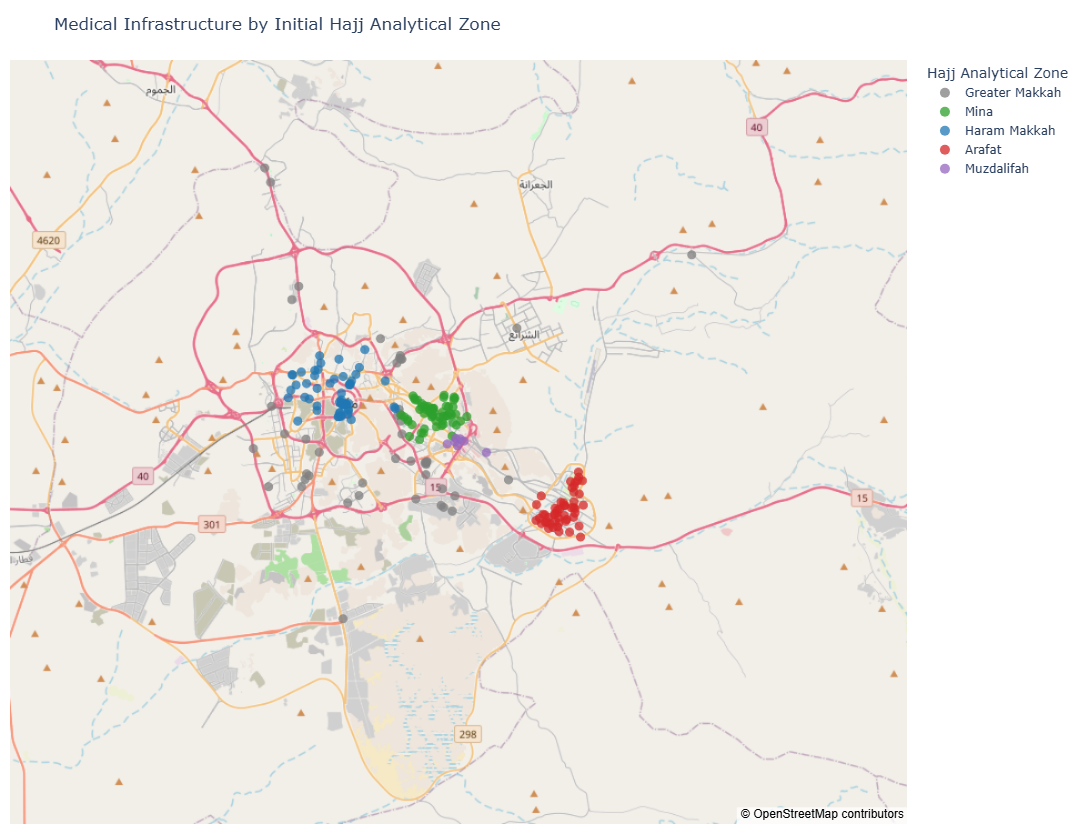

In [ ]:
# =========================================================
# 8B. PLOTLY INTERACTIVE VALIDATION MAP
# =========================================================

# Create a copy for visualization
plot_df = locations_zoned.copy()

# Friendly labels
plot_df["zone_label"] = (
    plot_df["hajj_zone"]
    .str.replace("_", " ", regex=False)
)

plot_df["category_label"] = (
    plot_df["category"]
    .str.replace("_", " ", regex=False)
    .str.title()
)


# ---------------------------------------------------------
# Define zone colors
# ---------------------------------------------------------

PLOTLY_ZONE_COLORS = {
    "Haram Makkah": "#1f77b4",
    "Mina": "#2ca02c",
    "Muzdalifah": "#9467bd",
    "Arafat": "#d62728",
    "Greater Makkah": "#7f7f7f"
}


# ---------------------------------------------------------
# Calculate map center
# ---------------------------------------------------------

plot_center_lat = float(
    zone_centers["latitude"].mean()
)

plot_center_lon = float(
    zone_centers["longitude"].mean()
)


# ---------------------------------------------------------
# Create Plotly map
# ---------------------------------------------------------

fig = px.scatter_map(

    plot_df,

    lat="latitude",

    lon="longitude",

    color="zone_label",

    color_discrete_map=PLOTLY_ZONE_COLORS,

    hover_name="map_name",

    hover_data={

        "name_ar": True,

        "category_label": True,

        "osm_completeness_score": True,

        "needs_manual_review": True,

        "latitude": ":.6f",

        "longitude": ":.6f"

    },

    center={
        "lat": plot_center_lat,
        "lon": plot_center_lon
    },

    zoom=10,

    height=820,

    title=(
        "Medical Infrastructure by "
        "Initial Hajj Analytical Zone"
    )
)


# ---------------------------------------------------------
# Layout
# ---------------------------------------------------------

fig.update_layout(

    map_style="open-street-map",

    legend_title_text="Hajj Analytical Zone",

    margin={
        "r": 10,
        "t": 60,
        "l": 10,
        "b": 10
    }
)


# ---------------------------------------------------------
# Improve marker appearance
# ---------------------------------------------------------

fig.update_traces(
    marker={
        "size": 10,
        "opacity": 0.75
    }
)


# ---------------------------------------------------------
# Save Plotly map
# ---------------------------------------------------------

plotly_path = (
    MAP_DIR /
    "hajj_zones_facility_validation_plotly.html"
)

fig.write_html(
    plotly_path,
    include_plotlyjs="cdn"
)

print("Saved:", plotly_path)


# ---------------------------------------------------------
# Display
# ---------------------------------------------------------

fig.show()

## 9. Export zoned datasets and validation reports


In [ ]:
zoned_gpkg=PROCESSED_DIR/"hajj_medical_locations_zoned_v1.gpkg"
zoned_parquet=PROCESSED_DIR/"hajj_medical_locations_zoned_v1.parquet"
zones_gpkg=PROCESSED_DIR/"hajj_analytical_zones_v1.gpkg"

locations_zoned.to_file(zoned_gpkg,layer="medical_locations_zoned",driver="GPKG")
locations_zoned.to_parquet(zoned_parquet,index=False)
zones.to_file(zones_gpkg,layer="analytical_zones",driver="GPKG")
zone_centers.drop(columns="geometry").to_csv(PROCESSED_DIR/"hajj_zone_centers_v1.csv",index=False,encoding="utf-8-sig")
review.drop(columns="geometry").to_csv(REPORT_DIR/"facilities_manual_review_v1.csv",index=False,encoding="utf-8-sig")
zone_summary.to_csv(REPORT_DIR/"hajj_zone_summary_v1.csv",index=False,encoding="utf-8-sig")
zone_category_counts.to_csv(REPORT_DIR/"hajj_zone_category_counts_v1.csv",encoding="utf-8-sig")
print("Exports complete.")


Exports complete.
